## 1) Importing libraries

### 1.1) Instaling

In [1]:
!pip install tensorflow==2.21

In [2]:
!pip install tf2onnx

### 1.2) Importing libraries

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os
import shutil

## 1.3) Setting up drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2) Reading datasets

In [5]:
train_raw = np.load(file = "./drive/MyDrive/numpy/train.npy")
test_raw = np.load(file = "./drive/MyDrive/numpy/test.npy")
val_raw = np.load(file = "./drive/MyDrive/numpy/val.npy")

# 2. Separa X (Imagens) e Y (Máscaras) convertendo explicitamente para float32 e normalizando
X_train = (train_raw[:, 0].astype("float32")) / 255.0
y_train = (train_raw[:, 1].astype("float32")) / 255.0

X_val = (val_raw[:, 0].astype("float32")) / 255.0
y_val = (val_raw[:, 1].astype("float32")) / 255.0

X_test = (test_raw[:, 0].astype("float32")) / 255.0
y_test = (test_raw[:, 1].astype("float32")) / 255.0

# 3. Adiciona o canal de cinzas no final de cada array isolado
X_train = np.expand_dims(X_train, axis=-1)
y_train = np.expand_dims(y_train, axis=-1)

X_val = np.expand_dims(X_val, axis=-1)
y_val = np.expand_dims(y_val, axis=-1)

X_test = np.expand_dims(X_test, axis=-1)
y_test = np.expand_dims(y_test, axis=-1)

# Validação visual dos shapes no seu terminal
print("X_train:", X_train.shape) # Deve printar: (4000, 256, 256, 1)
print("y_train:", y_train.shape) # Deve printar: (4000, 256, 256, 1)
print("X_val:", X_val.shape)     # Deve printar: (400, 256, 256, 1)

X_train: (15874, 256, 256, 1)
y_train: (15874, 256, 256, 1)
X_val: (529, 256, 256, 1)


## 3) Creating model

### 3.1) Defining architeture

In [6]:
def build_model(input_shape=(256, 256, 1)):
    inputs = layers.Input(shape=input_shape)

    # --- ENCODER (Descida do U) ---
    # Nível 1 (256x256)
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.BatchNormalization()(c1)
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1) # Reduz para 128x128

    # Nível 2 (128x128)
    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.BatchNormalization()(c2)
    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2) # Reduz para 64x64

    # Nível 3 (64x64)
    c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.BatchNormalization()(c3)
    c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3) # Reduz para 32x32

    # --- GARGALO / BASE DO U (32x32) ---
    c4 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c4)

    # --- DECODER (Subida do U com as conexões de salto) ---
    # Sobe para 64x64
    u5 = layers.UpSampling2D((2, 2))(c4)
    concat5 = layers.Concatenate()([u5, c3]) # Puxa do Nível 3
    c5 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(concat5)

    # Sobe para 128x128
    u6 = layers.UpSampling2D((2, 2))(c5)
    concat6 = layers.Concatenate()([u6, c2]) # Puxa do Nível 2
    c6 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(concat6)

    # Sobe para 256x256
    u7 = layers.UpSampling2D((2, 2))(c6)
    concat7 = layers.Concatenate()([u7, c1]) # Puxa do Nível 1
    c7 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(concat7)

    # Camada de saída pixel a pixel
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c7)

    modelo = models.Model(inputs=[inputs], outputs=[outputs])
    return modelo

# Instancia o modelo
model = build_model(input_shape=(256, 256, 1))

model.summary(show_trainable = True)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer       │ (None, 256,     │         0 │ -              │   -   │
│ (InputLayer)      │ 256, 1)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ conv2d (Conv2D)   │ (None, 256,     │       320 │ input_layer[0… │   Y   │
│                   │ 256, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ batch_normalizat… │ (None, 256,     │       128 │ conv2d[0][0]   │   Y   │
│ (BatchNormalizat… │ 256, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ conv2d_1 (Conv2D) │ (None, 256,     │     9,248 │ batch_normali… │   Y   │
│                   │ 256, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ max_pooling2d     │ (None, 128,     │         0 │ conv2d_1[0][0] │   -   │
│ (MaxPooling2D)    │ 128, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ conv2d_2 (Conv2D) │ (None, 128,     │    18,496 │ max_pooling2d… │   Y   │
│                   │ 128, 64)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ batch_normalizat… │ (None, 128,     │       256 │ conv2d_2[0][0] │   Y   │
│ (BatchNormalizat… │ 128, 64)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ conv2d_3 (Conv2D) │ (None, 128,     │    36,928 │ batch_normali… │   Y   │
│                   │ 128, 64)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ max_pooling2d_1   │ (None, 64, 64,  │         0 │ conv2d_3[0][0] │   -   │
│ (MaxPooling2D)    │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ conv2d_4 (Conv2D) │ (None, 64, 64,  │    73,856 │ max_pooling2d… │   Y   │
│                   │ 128)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ batch_normalizat… │ (None, 64, 64,  │       512 │ conv2d_4[0][0] │   Y   │
│ (BatchNormalizat… │ 128)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ conv2d_5 (Conv2D) │ (None, 64, 64,  │   147,584 │ batch_normali… │   Y   │
│                   │ 128)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ max_pooling2d_2   │ (None, 32, 32,  │         0 │ conv2d_5[0][0] │   -   │
│ (MaxPooling2D)    │ 128)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ conv2d_6 (Conv2D) │ (None, 32, 32,  │   295,168 │ max_pooling2d… │   Y   │
│                   │ 256)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ conv2d_7 (Conv2D) │ (None, 32, 32,  │   590,080 │ conv2d_6[0][0] │   Y   │
│                   │ 256)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ up_sampling2d     │ (None, 64, 64,  │         0 │ conv2d_7[0][0] │   -   │
│ (UpSampling2D)    │ 256)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ concatenate       │ (None, 64, 64,  │         0 │ up_sampling2d… │   - 

 Total params: 1,753,441 (6.69 MB)

 Trainable params: 1,752,993 (6.69 MB)

 Non-trainable params: 448 (1.75 KB)

### 3.2) Metric

In [7]:
def dice_coefficient(y_true, y_pred):
    smooth = 1e-5

    # Keras Flatten lida de forma segura com o batch no Keras 3 / TensorFlow backend
    y_true_f = layers.Flatten()(y_true)
    y_pred_f = layers.Flatten()(y_pred)

    # Interseção pixel a pixel
    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=-1)

    # Soma das áreas das matrizes
    soma_matrizes = tf.reduce_sum(y_true_f, axis=-1) + tf.reduce_sum(y_pred_f, axis=-1)

    # Retorna a média do lote
    return tf.reduce_mean((2. * intersection + smooth) / (soma_matrizes + smooth))

# 3. COMPILAÇÃO DO MODELO
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = [dice_coefficient],
    # run_eagerly = True  # Força o Keras a processar as matrizes como tensores dinâmicos tradicionais
)

### 3.3) Training

In [8]:
# 4. TREINAMENTO
history = model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = 100,
    batch_size = 16,
    shuffle = True,
    callbacks = [
      tf.keras.callbacks.EarlyStopping(
          monitor = "val_dice_coefficient",
          min_delta = 1E-3,
          patience = 5,
          verbose = 1,
          mode = "max",
      ),
      tf.keras.callbacks.ModelCheckpoint(
        filepath = "./drive/MyDrive/numpy/checkpoint.keras",
        monitor = 'val_dice_coefficient',
        save_best_only = True,
        verbose = 1,
        mode = 'max'
      )
    ]
)

Epoch 1/100
993/993 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - dice_coefficient: 0.8291 - loss: 0.1342
Epoch 1: val_dice_coefficient improved from None to 0.91157, saving model to ./drive/MyDrive/numpy/checkpoint.keras

Epoch 1: finished saving model to ./drive/MyDrive/numpy/checkpoint.keras
993/993 ━━━━━━━━━━━━━━━━━━━━ 241s 211ms/step - dice_coefficient: 0.9090 - loss: 0.0710 - val_dice_coefficient: 0.9116 - val_loss: 0.0918
Epoch 2/100
992/993 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - dice_coefficient: 0.9584 - loss: 0.0326
Epoch 2: val_dice_coefficient improved from 0.91157 to 0.95856, saving model to ./drive/MyDrive/numpy/checkpoint.keras

Epoch 2: finished saving model to ./drive/MyDrive/numpy/checkpoint.keras
993/993 ━━━━━━━━━━━━━━━━━━━━ 117s 118ms/step - dice_coefficient: 0.9611 - loss: 0.0301 - val_dice_coefficient: 0.9586 - val_loss: 0.0391
Epoch 3/100
992/993 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - dice_coefficient: 0.9646 - loss: 0.0271
Epoch 3: val_dice_coefficient improved from 0.95856 

## 4) Plot training

In [9]:
def plot_history(history, title):
  fig, axs = plt.subplots(
    figsize = (20, 5),
    ncols = 2,
  )

  axs[0].plot(
      history.epoch, history.history["val_loss"], "C1", label = "val_loss"
  )
  axs[0].plot(
      history.epoch, history.history["loss"], "C0", label = "loss"
  )

  axs[1].plot(
      history.epoch, history.history["val_dice_coefficient"], "C1", label = "val_dice_coefficient"
  )
  axs[1].plot(
      history.epoch, history.history["dice_coefficient"], "C0", label = "dice_coefficient"
  )

  axs[0].set_title(
      label = "loss evolution",
      fontsize = 16,
      fontweight = "bold",
  )

  axs[0].spines[["top", "right"]].set_visible(False)
  axs[0].set_xlabel(xlabel = "epoch")
  axs[0].set_ylabel(ylabel = "loss")
  axs[0].legend()

  axs[1].set_title(
      label = "sparse_categorical_accuracy evolution",
      fontsize = 16,
      fontweight = "bold",
  )

  axs[1].spines[["top", "right"]].set_visible(False)
  axs[1].set_xlabel(xlabel = "epoch")
  axs[1].set_ylabel(ylabel = "dice_coefficient")
  axs[1].legend()

  plt.suptitle(t = title, fontsize = 24, fontweight = "bold")
  plt.show()

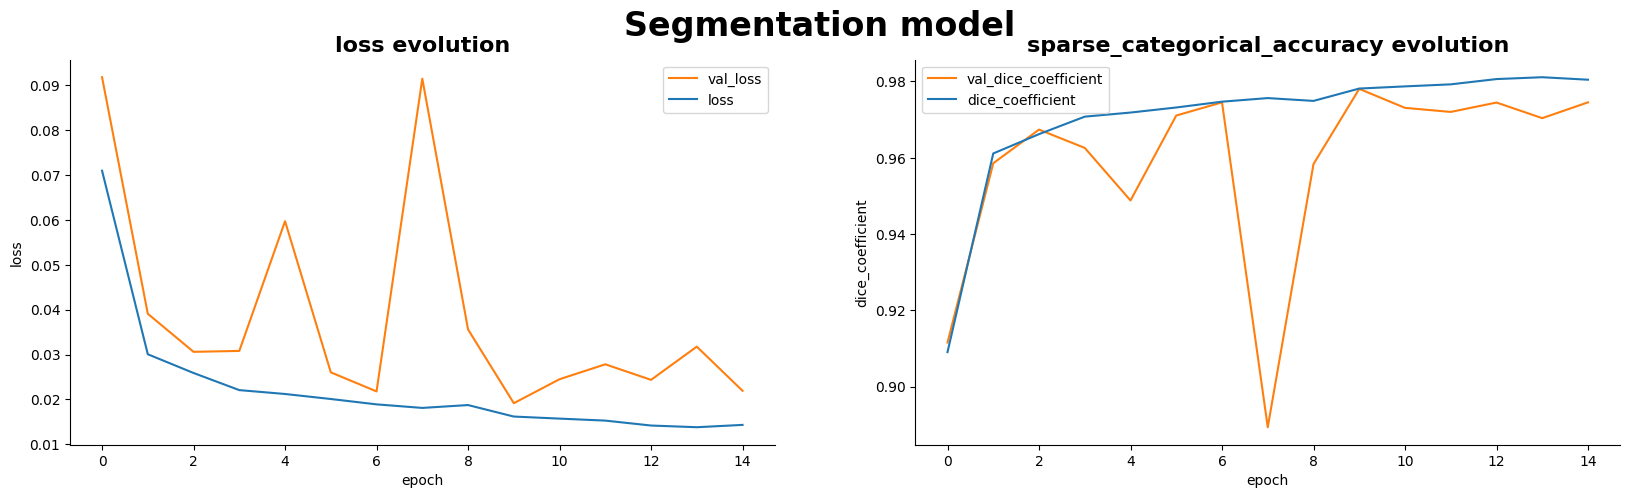

In [10]:
plot_history(history, "Segmentation model")

In [11]:
paths = [
    "./drive/MyDrive/numpy/checkpoint.keras",
]

for path in paths:
    print(f"Lendo e preparando o modelo: {path}")
    try:
        # 1. Carrega o modelo ignorando as métricas de treino (Evita o erro do dice_coefficient)
        model = tf.keras.models.load_model(path, compile=False)

        # 2. Caminhos temporários para o formato SavedModel do TensorFlow
        temp_saved_model_dir = "./temp_saved_model"
        onnx_path = path.replace('.keras', '.onnx')

        # Limpa o diretório temporário se ele já existir de uma execução travada anterior
        if os.path.exists(temp_saved_model_dir):
            shutil.rmtree(temp_saved_model_dir)

        # 3. Exporta para SavedModel (o formato de produção nativo do TF)
        print("Exportando para formato SavedModel...")
        model.export(temp_saved_model_dir)

        # 4. Chama o pacote tf2onnx direto pelo terminal do sistema
        print(f"Convertendo via CLI do tf2onnx...")
        # Adicionei o comando de execução usando o módulo python diretamente
        comando_cli = f"python -m tf2onnx.convert --saved-model {temp_saved_model_dir} --output {onnx_path} --opset 15"

        status = os.system(comando_cli)

        if status != 0:
            raise RuntimeError("O comando tf2onnx falhou. Certifique-se de que a biblioteca 'tf2onnx' está instalada no seu ambiente virtual.")

        # Limpa a pasta temporária criada de forma segura
        shutil.rmtree(temp_saved_model_dir)

        print(f"  Sucesso absoluto! Arquivo .onnx pronto para o AWS Lambda gerado em: {onnx_path}\n")

    except Exception as e:
        print(f"  Erro ao converter o modelo {path}: {e}\n")

Lendo e preparando o modelo: ./drive/MyDrive/numpy/checkpoint.keras
Exportando para formato SavedModel...
Saved artifact at './temp_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name='input_layer')]
Output Type:
  TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None)
Captures:
  134121501919568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134121501919760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134121501919376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134121501917264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134121501917456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134121501918032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134121501917840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134121501919184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134121501918224: TensorSpec(sha